## Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Load Dataset

This data set contains records of ***416*** patients diagnosed with liver disease and ***167*** patients without liver disease. This information is contained in the class label named 'Selector'.  There are 10 variables per patient: age, gender, total Bilirubin, direct Bilirubin, total proteins, albumin, A/G ratio, SGPT, SGOT and Alkphos. Of the ***583*** patient records, ***441*** are male, and ***142*** are female.



In [ ]:
file_path = "/content/Indian Liver Patient Dataset (ILPD).csv"

df = pd.read_csv(file_path, header=None)

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## Provide Column names

In [ ]:
column_names = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
    "Result"   # 1 = Liver disease, 2 = No liver disease
]

df.columns = column_names

In [ ]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## Boxplot and violin plotting for each column

Here we can define
- Quartile 1 (25% values are below this range)
- Quartile 3 (75% values are below this range)
- Inter Quartile Range (In general 50% of the data lies within Q1 and Q3 [Q3-Q1])
- Median (50% of the data points are below this value)
- Outliers (The distinct points that are very much further from the main distribution)

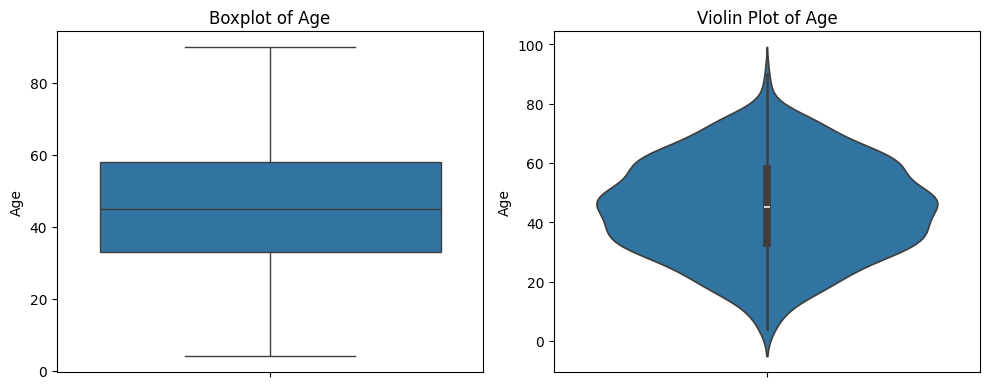

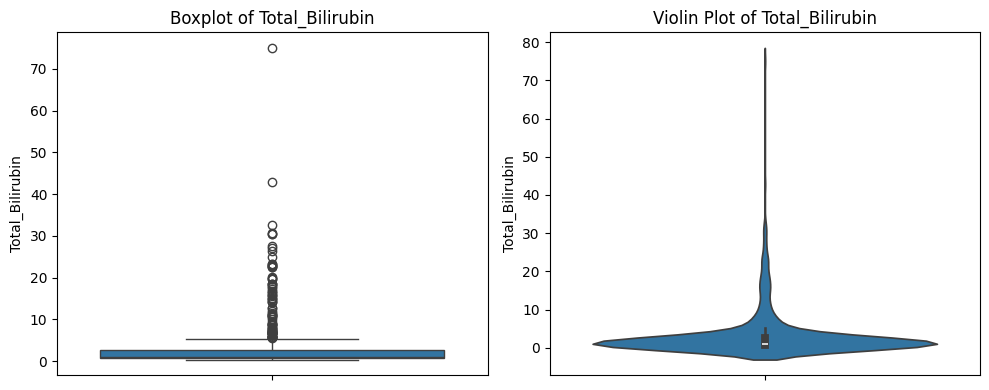

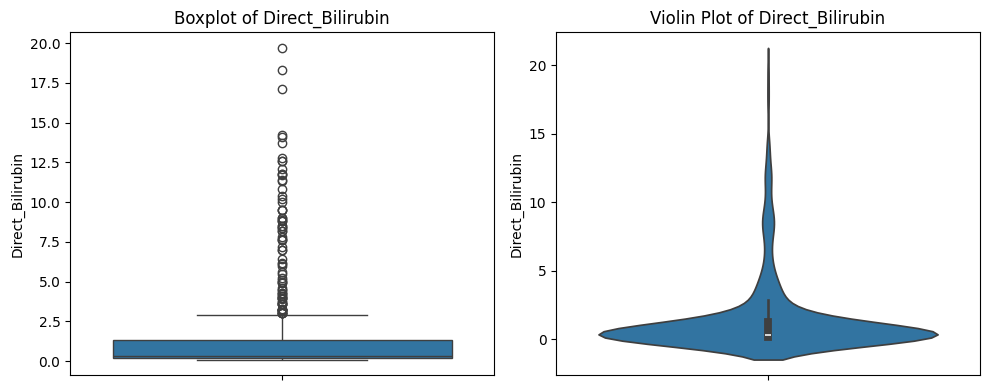

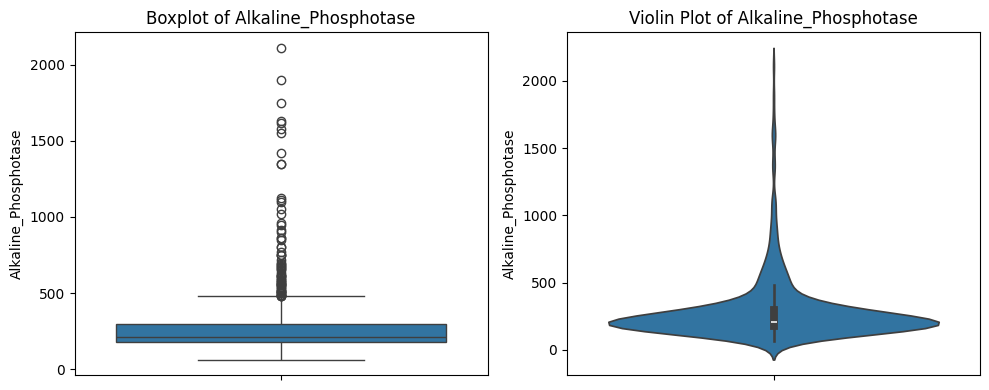

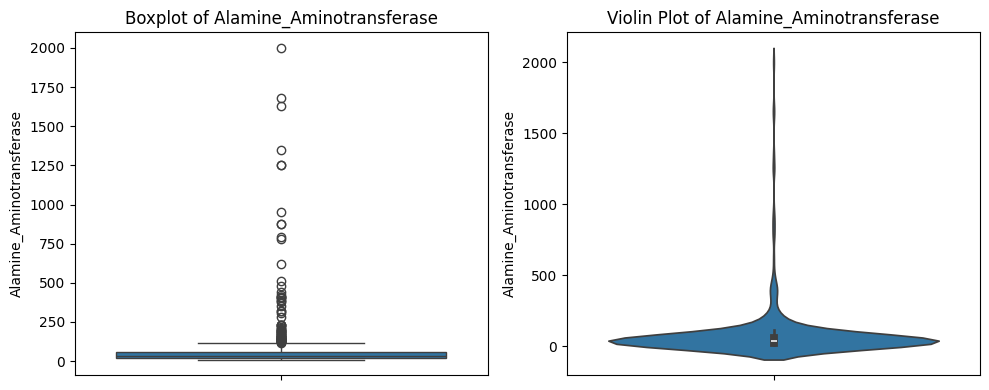

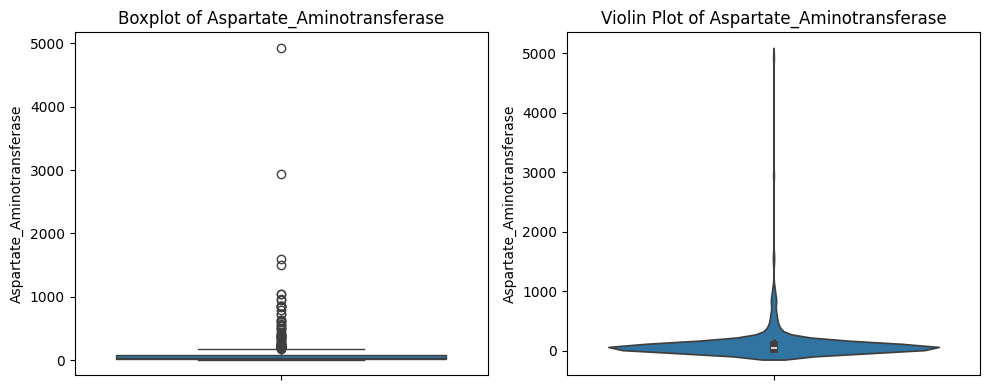

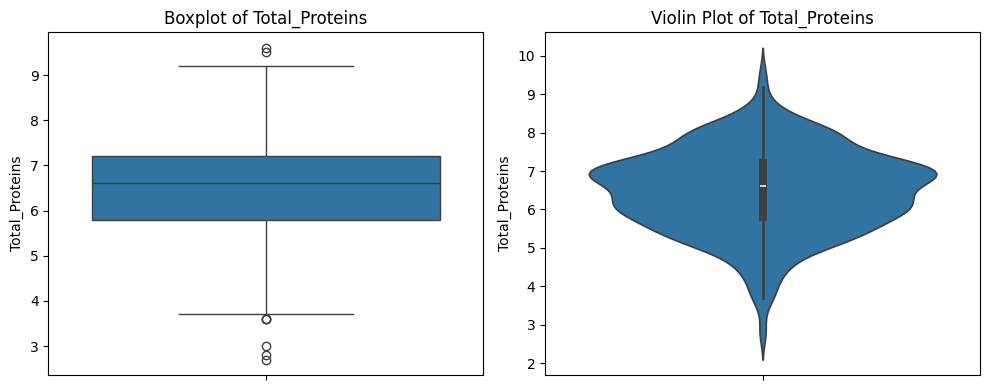

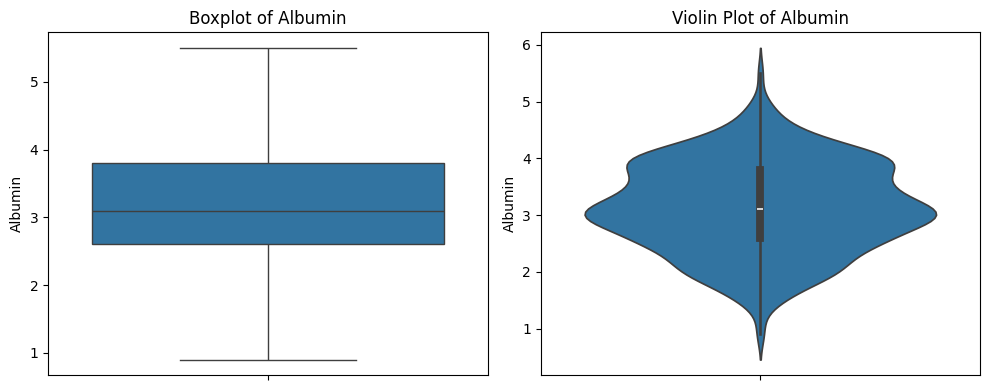

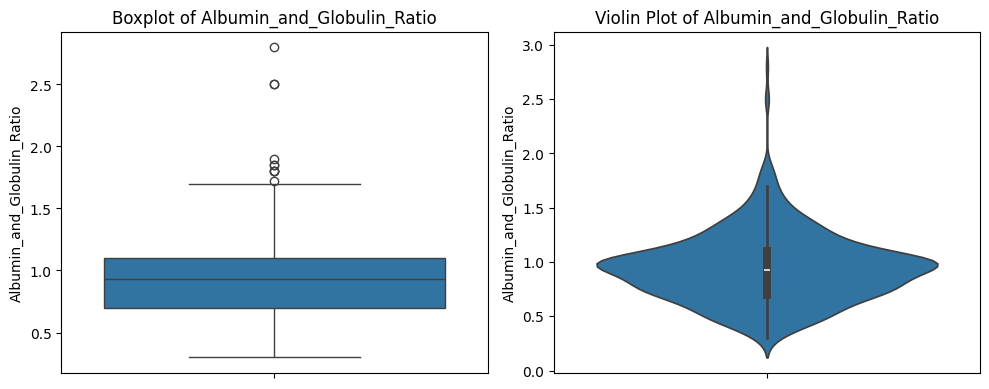

In [ ]:
# Select only numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('Result')


# Plot boxplot and violin plot side by side for each numeric column
for col in numeric_columns:

    plt.figure(figsize=(10,4))

    # Boxplot
    plt.subplot(1,2,1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

    # Violin Plot
    plt.subplot(1,2,2)
    sns.violinplot(y=df[col])
    plt.title(f"Violin Plot of {col}")

    plt.tight_layout()
    plt.show()

## IQR values along with Q1 and Q3 values (IQR=Q3-Q1)

In [ ]:
iqr_table = pd.DataFrame(columns=["Q1", "Q3", "IQR"])

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    iqr_table.loc[col] = [Q1, Q3, IQR]

print(iqr_table)

                               Q1     Q3    IQR
Age                          33.0   58.0   25.0
Total_Bilirubin               0.8    2.6    1.8
Direct_Bilirubin              0.2    1.3    1.1
Alkaline_Phosphotase        175.5  298.0  122.5
Alamine_Aminotransferase     23.0   60.5   37.5
Aspartate_Aminotransferase   25.0   87.0   62.0
Total_Proteins                5.8    7.2    1.4
Albumin                       2.6    3.8    1.2
Albumin_and_Globulin_Ratio    0.7    1.1    0.4


## Detecting Clinically impossible values

In [ ]:
# Physiological limits defined by you
limits = {
    "Age": (0,100),
    "Total_Bilirubin": (0,50),
    "Direct_Bilirubin": (0,30),
    "Alkaline_Phosphotase": (0,2000),
    "Alamine_Aminotransferase": (0,5000),
    "Aspartate_Aminotransferase": (0,10000),
    "Total_Proteins": (0,15),
    "Albumin": (0,6.0),
    "Albumin_and_Globulin_Ratio": (0,3.0)
}

# Detect impossible values
invalid_counts = {}

for col, (low, high) in limits.items():
    invalid = df[(df[col] < low) | (df[col] > high)]
    invalid_counts[col] = len(invalid)

print("Impossible values detected:\n")

for k,v in invalid_counts.items():
    print(f"{k} : {v}")

Impossible values detected:

Age : 0
Total_Bilirubin : 1
Direct_Bilirubin : 0
Alkaline_Phosphotase : 1
Alamine_Aminotransferase : 0
Aspartate_Aminotransferase : 0
Total_Proteins : 0
Albumin : 0
Albumin_and_Globulin_Ratio : 0


## Kurtosis value calculation along with histogram and density curve plotting

### Kurtosis Formula

Kurtosis measures how heavy the tails of a distribution are. (basically influence of outliers in the overall distribution)

$$
\text{Kurtosis} =
\frac{1}{N} \sum_{i=1}^{N}
\left(\frac{x_i - \mu}{\sigma}\right)^4
$$

Where:

- $x_i$ = Each data value  
- $\mu$ = Mean of the distribution  
- $\sigma$ = Standard deviation of the distribution
- $N$ = Number of observations  
- $\sum$ = Summation of values



## Skewness value calculation along with histogram and density curve plotting

### Skewness Formula

Skewness measures the asymmetry of the distribution.

$$
\text{Skewness} = \frac{1}{N} \sum_{i=1}^{N} \left(\frac{x_i - \mu}{\sigma}\right)^3
$$

Where:

- $x_i$ = Each data point in the distribution  
- $\mu$ = Mean of the distribution
- $\sigma$ = Standard deviation of the distribution  
- $N$ = Total number of observations  
- $\sum$ = Summation of all values from $i=1$ to $N$

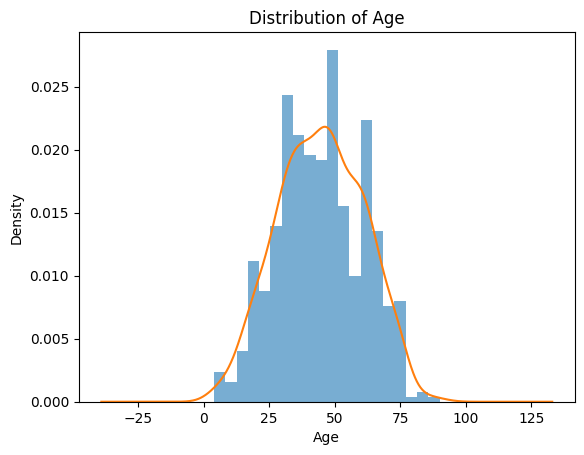

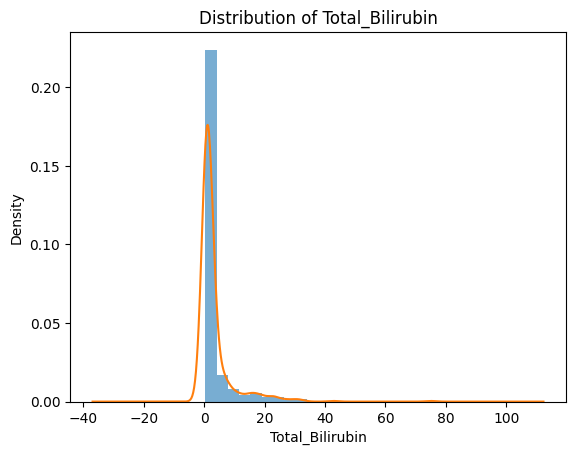

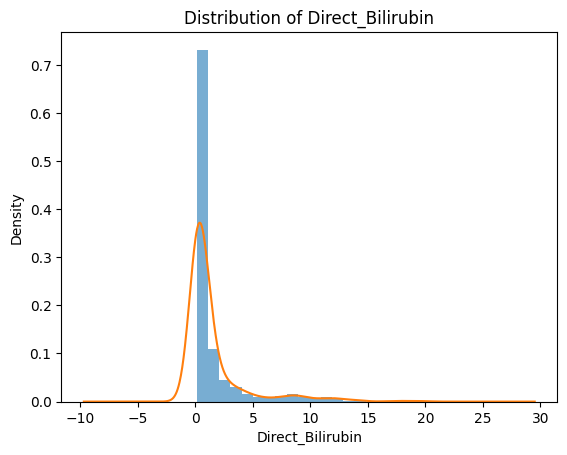

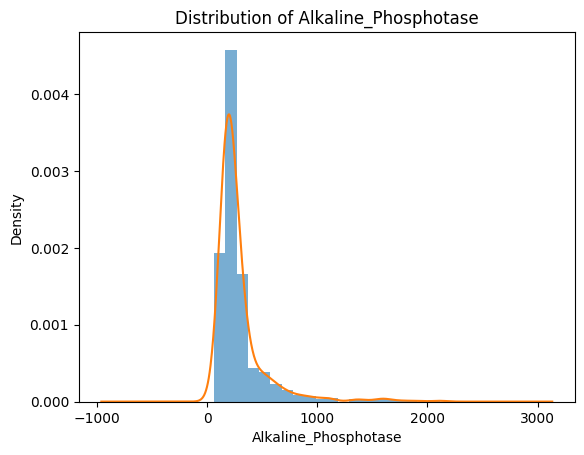

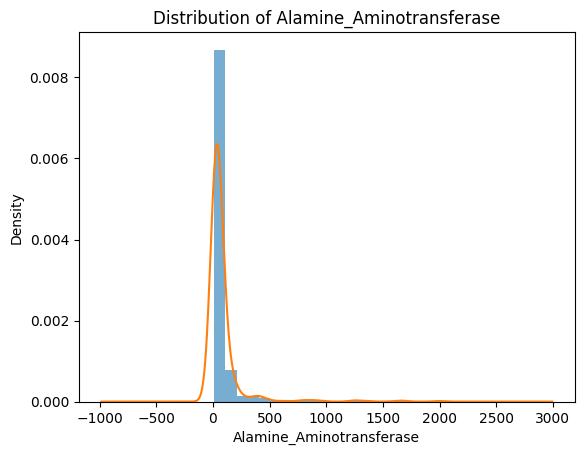

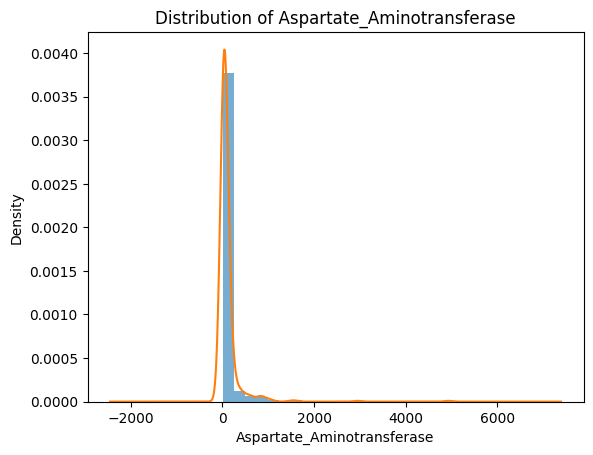

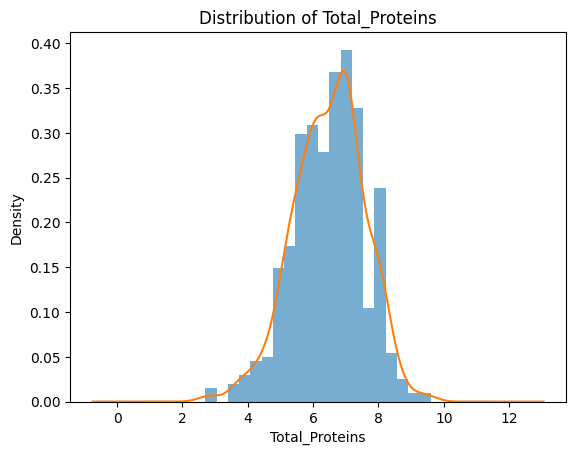

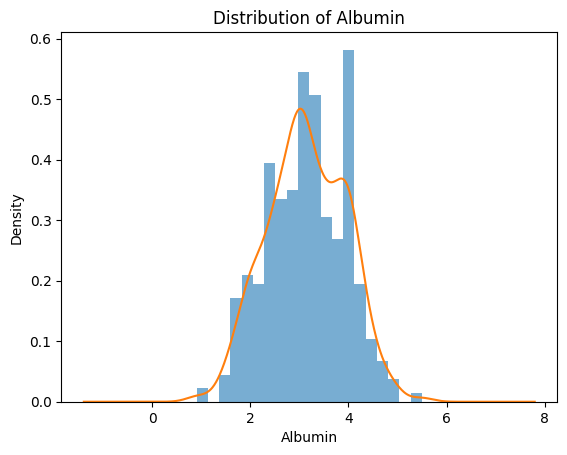

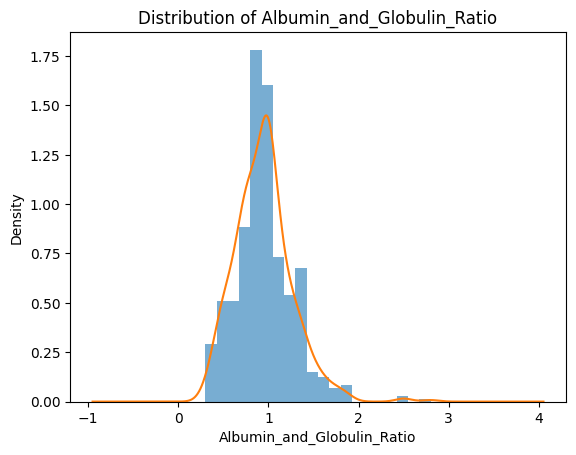


Skewness and Kurtosis Comparison Table

                      Feature   Skewness    Kurtosis
0                         Age  -0.029310    2.434452
1             Total_Bilirubin   4.894839   39.835553
2            Direct_Bilirubin   3.204132   14.245125
3        Alkaline_Phosphotase   3.755412   20.590666
4    Alamine_Aminotransferase   6.532329   53.136430
5  Aspartate_Aminotransferase  10.519024  152.618375
6              Total_Proteins  -0.284937    3.220771
7                     Albumin  -0.043572    2.605140
8  Albumin_and_Globulin_Ratio   0.989727    6.243282


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select numeric columns except target
numeric_columns = df.select_dtypes(include=['int64','float64']).columns.drop('Result', errors='ignore')

# List to store skewness and kurtosis values
stats_list = []

# Loop through columns
for col in numeric_columns:

    data = df[col].dropna()

    # ----- Plot Graph -----
    plt.figure()

    data.plot(
        kind='hist',
        bins=20,
        density=True,
        alpha=0.6
    )

    data.plot(kind='kde')

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.show()

    # ----- Manual Skewness Calculation -----
    n = len(data)
    mean = np.mean(data)
    std = np.std(data)

    skewness = np.sum((data - mean)**3) / n
    skewness = skewness / (std**3)

    # ----- Manual Kurtosis Calculation -----
    kurtosis = np.sum((data - mean)**4) / (n * (std**4))

    # Store results
    stats_list.append([col, skewness, kurtosis])

# Convert to DataFrame
stats_table = pd.DataFrame(stats_list, columns=["Feature", "Skewness", "Kurtosis"])

# Show table
print("\nSkewness and Kurtosis Comparison Table\n")
print(stats_table)

## Mean Median and Standard Deviation calculation

In [ ]:
# Calculate statistics
mean_values = df.mean(numeric_only=True)
median_values = df.median(numeric_only=True)
std_values = df.std(numeric_only=True)

# Create table
stats_table = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Standard Deviation": std_values
})

print(stats_table)

                                  Mean  Median  Standard Deviation
Age                          44.746141   45.00           16.189833
Total_Bilirubin               3.298799    1.00            6.209522
Direct_Bilirubin              1.486106    0.30            2.808498
Alkaline_Phosphotase        290.576329  208.00          242.937989
Alamine_Aminotransferase     80.713551   35.00          182.620356
Aspartate_Aminotransferase  109.910806   42.00          288.918529
Total_Proteins                6.483190    6.60            1.085451
Albumin                       3.141852    3.10            0.795519
Albumin_and_Globulin_Ratio    0.947064    0.93            0.319592
Result                        1.286449    1.00            0.452490


## no. of values exceeding normal pathological range

In [ ]:
# Define clinical ranges
clinical_ranges = {
    "Total_Bilirubin": (0.1, 1.2),
    "Direct_Bilirubin": (0, 0.3),   # <0.3
    "Alamine_Aminotransferase": (7, 56),   # ALT
    "Aspartate_Aminotransferase": (10, 40), # AST
    "Alkaline_Phosphotase": (44, 147),      # ALP
    "Albumin": (3.5, 5.5),
    "Total_Proteins": (6, 8.3),
    "Albumin_and_Globulin_Ratio": (1.1, 2.5)
}

# Dictionary to store results
out_of_range_counts = {}

for col, (low, high) in clinical_ranges.items():

    if col in df.columns:
        count = ((df[col] < low) | (df[col] > high)).sum()
        out_of_range_counts[col] = count

# Convert to DataFrame
out_of_range_table = pd.DataFrame.from_dict(
    out_of_range_counts, orient='index', columns=['Out_of_Range_Count']
)

print(out_of_range_table)

                            Out_of_Range_Count
Total_Bilirubin                            251
Direct_Bilirubin                           275
Alamine_Aminotransferase                   162
Aspartate_Aminotransferase                 300
Alkaline_Phosphotase                       528
Albumin                                    372
Total_Proteins                             188
Albumin_and_Globulin_Ratio                 408


## Infected patients with at least one abnormal value (to check the trend which one having the most abnormal values to make the result infected)

In [ ]:
# Create mask for abnormal rows
mask = pd.Series(False, index=df.index)

for col, (low, high) in clinical_ranges.items():
    if col in df.columns:
        mask |= (df[col] < low) | (df[col] > high)

out_of_range_rows = df[mask]

infected_rows = out_of_range_rows[out_of_range_rows["Result"] == 1]
healthy_rows = out_of_range_rows[out_of_range_rows["Result"] == 2]

def highlight_out_of_range(val, col_name):
    if col_name in clinical_ranges:
        low, high = clinical_ranges[col_name]
        if val < low or val > high:
            return "background-color: orange"
    return ""

infected_styled = infected_rows.style.apply(
    lambda row: [
        highlight_out_of_range(row[col], col) if col in clinical_ranges else ""
        for col in row.index
    ],
    axis=1
)

infected_styled

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
0,65,Female,0.700000,0.100000,187,16,18,6.800000,3.300000,0.900000,1
1,62,Male,10.900000,5.500000,699,64,100,7.500000,3.200000,0.740000,1
2,62,Male,7.300000,4.100000,490,60,68,7.000000,3.300000,0.890000,1
3,58,Male,1.000000,0.400000,182,14,20,6.800000,3.400000,1.000000,1
4,72,Male,3.900000,2.000000,195,27,59,7.300000,2.400000,0.400000,1
5,46,Male,1.800000,0.700000,208,19,14,7.600000,4.400000,1.300000,1
6,26,Female,0.900000,0.200000,154,16,12,7.000000,3.500000,1.000000,1
7,29,Female,0.900000,0.300000,202,14,11,6.700000,3.600000,1.100000,1
9,55,Male,0.700000,0.200000,290,53,58,6.800000,3.400000,1.000000,1
10,57,Male,0.600000,0.100000,210,51,59,5.900000,2.700000,0.800000,1


## Healthy rows with at least one abnormal values (to check how many healthy patients have abnormal values)

In [ ]:
healthy_styled = healthy_rows.style.apply(
    lambda row: [
        highlight_out_of_range(row[col], col) if col in clinical_ranges else ""
        for col in row.index
    ],
    axis=1
)

healthy_styled

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
8,17,Male,0.900000,0.300000,202,22,19,7.400000,4.100000,1.200000,2
12,64,Male,0.900000,0.300000,310,61,58,7.000000,3.400000,0.900000,2
15,25,Male,0.600000,0.100000,183,91,53,5.500000,2.300000,0.700000,2
17,33,Male,1.600000,0.500000,165,15,23,7.300000,3.500000,0.920000,2
24,63,Male,0.900000,0.200000,194,52,45,6.000000,3.900000,1.850000,2
28,20,Male,1.100000,0.500000,128,20,30,3.900000,1.900000,0.950000,2
29,84,Female,0.700000,0.200000,188,13,21,6.000000,3.200000,1.100000,2
32,57,Male,1.000000,0.300000,187,19,23,5.200000,2.900000,1.200000,2
33,38,Female,2.600000,1.200000,410,59,57,5.600000,3.000000,0.800000,2
34,38,Female,2.600000,1.200000,410,59,57,5.600000,3.000000,0.800000,2


In [ ]:
print(len(infected_rows))
print(len(healthy_rows))

413
161


## Gender wise classification

In [ ]:
abnormal_mask = pd.Series(False, index=df.index)

for col, (low, high) in clinical_ranges.items():
    if col in df.columns:
        abnormal_mask |= (df[col] < low) | (df[col] > high)

infected_normal = df[(df["Result"] == 1) & (~abnormal_mask)]
healthy_abnormal = df[(df["Result"] == 2) & (abnormal_mask)]

# Infected but normal
infected_normal_male = infected_normal[infected_normal["Gender"] == "Male"]
infected_normal_female = infected_normal[infected_normal["Gender"] == "Female"]

# Healthy but abnormal
healthy_abnormal_male = healthy_abnormal[healthy_abnormal["Gender"] == "Male"]
healthy_abnormal_female = healthy_abnormal[healthy_abnormal["Gender"] == "Female"]

infected_gender_counts = infected_normal["Gender"].value_counts()
healthy_gender_counts = healthy_abnormal["Gender"].value_counts()

print("\nCounts for each category:")

print("infected_normal_male:", len(infected_normal_male))
print("infected_normal_female:", len(infected_normal_female))

print("healthy_abnormal_male:", len(healthy_abnormal_male))
print("healthy_abnormal_female:", len(healthy_abnormal_female))


Counts for each category:
infected_normal_male: 0
infected_normal_female: 3
healthy_abnormal_male: 115
healthy_abnormal_female: 46


In [ ]:
def highlight_abnormal(val, col):
    if col in clinical_ranges:
        low, high = clinical_ranges[col]
        if val < low or val > high:
            return "background-color: orange"
    return ""

def highlight_normal(val, col):
    if col in clinical_ranges:
        low, high = clinical_ranges[col]
        if low <= val <= high:
            return "background-color: green"
    return ""

## Male entries with abnormal biomarker values but healthy

In [ ]:
infected_table = healthy_abnormal_male.style.apply(
    lambda row: [highlight_abnormal(row[col], col) if col in clinical_ranges else ""
                 for col in row.index],
    axis=1
)

infected_table

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
8,17,Male,0.900000,0.300000,202,22,19,7.400000,4.100000,1.200000,2
12,64,Male,0.900000,0.300000,310,61,58,7.000000,3.400000,0.900000,2
15,25,Male,0.600000,0.100000,183,91,53,5.500000,2.300000,0.700000,2
17,33,Male,1.600000,0.500000,165,15,23,7.300000,3.500000,0.920000,2
24,63,Male,0.900000,0.200000,194,52,45,6.000000,3.900000,1.850000,2
28,20,Male,1.100000,0.500000,128,20,30,3.900000,1.900000,0.950000,2
32,57,Male,1.000000,0.300000,187,19,23,5.200000,2.900000,1.200000,2
41,62,Male,0.600000,0.100000,160,42,110,4.900000,2.600000,1.100000,2
42,42,Male,6.800000,3.200000,630,25,47,6.100000,2.300000,0.600000,2
45,35,Male,1.800000,0.600000,275,48,178,6.500000,3.200000,0.900000,2


## Female entries with abnormal biomarker values but healthy

In [ ]:
infected_table = healthy_abnormal_female.style.apply(
    lambda row: [highlight_abnormal(row[col], col) if col in clinical_ranges else ""
                 for col in row.index],
    axis=1
)

infected_table

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
29,84,Female,0.700000,0.200000,188,13,21,6.000000,3.200000,1.100000,2
33,38,Female,2.600000,1.200000,410,59,57,5.600000,3.000000,0.800000,2
34,38,Female,2.600000,1.200000,410,59,57,5.600000,3.000000,0.800000,2
44,85,Female,1.000000,0.300000,208,17,15,7.000000,3.600000,1.000000,2
57,48,Female,0.900000,0.200000,175,24,54,5.500000,2.700000,0.900000,2
75,29,Female,0.700000,0.100000,162,52,41,5.200000,2.500000,0.900000,2
103,55,Female,0.800000,0.200000,225,14,23,6.100000,3.300000,1.200000,2
110,24,Female,0.700000,0.200000,188,11,10,5.500000,2.300000,0.710000,2
131,70,Female,0.700000,0.200000,237,18,28,5.800000,2.500000,0.750000,2
132,18,Female,0.800000,0.200000,199,34,31,6.500000,3.500000,1.160000,2


## Females with normal biomarker values but still infected

In [ ]:
healthy_table = infected_normal_female.style.apply(
    lambda row: [highlight_normal(row[col], col) if col in clinical_ranges else ""
                 for col in row.index],
    axis=1
)

healthy_table

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
267,43,Female,0.900000,0.300000,140,12,29,7.400000,3.500000,1.800000,1
352,26,Female,0.700000,0.200000,144,36,33,8.200000,4.300000,1.100000,1
369,58,Female,0.800000,0.200000,130,24,25,7.000000,4.000000,1.300000,1


## Function for highlighting abnormal values for healthy patient

In [ ]:
def highlight_abnormal(row):
    styles = []

    for col in row.index:
        if col in normal_ranges:
            low, high = normal_ranges[col]

            if row[col] < low or row[col] > high:
                styles.append('background-color: red')
            else:
                styles.append('')
        else:
            styles.append('')

    return styles

## Function for highlighting normal values for infected patient

In [ ]:
def highlight_normal(row):
    styles = []

    for col in row.index:
        if col in normal_ranges:
            low, high = normal_ranges[col]

            if low <= row[col] <= high:
                styles.append('background-color: green')
            else:
                styles.append('')
        else:
            styles.append('')

    return styles

## No. of entries where either patients being abnormal features are healthy or being normal features are infected

In [ ]:
import pandas as pd


# Normal ranges
normal_ranges = {
    "Total_Bilirubin": (0.1, 1.2),
    "Direct_Bilirubin": (0.0, 0.3),
    "Alkaline_Phosphotase": (44, 147),
    "Alamine_Aminotransferase": (7, 56),
    "Aspartate_Aminotransferase": (10, 40),
    "Total_Proteins": (6.0, 8.3),
    "Albumin": (3.5, 5.0),
    "Albumin_and_Globulin_Ratio": (0.8, 2.0)
}

# Function to check if all features are within normal range
def within_normal(row):
    for col, (low, high) in normal_ranges.items():
        if row[col] < low or row[col] > high:
            return False
    return True

# Apply function
df["within_normal"] = df.apply(within_normal, axis=1)

# Case 1: Healthy but abnormal values
healthy_abnormal = df[(df["Result"] == 2) & (df["within_normal"] == False)]

# Case 2: Infected but normal values
infected_normal = df[(df["Result"] == 1) & (df["within_normal"] == True)]

print("Healthy people with abnormal features:", len(healthy_abnormal))
print("Infected people with normal features:", len(infected_normal))

Healthy people with abnormal features: 161
Infected people with normal features: 3


## Highlighting the abnormal values for healthy and normal values for infected people

In [ ]:
pd.set_option('display.max_rows', None)
from IPython.display import display

print("\nHealthy but abnormal:")
display(healthy_abnormal.style.apply(highlight_abnormal, axis=1))

print("\nInfected but normal:")
display(infected_normal.style.apply(highlight_normal, axis=1))


Healthy but abnormal:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result,within_normal
8,17,Male,0.900000,0.300000,202,22,19,7.400000,4.100000,1.200000,2,False
12,64,Male,0.900000,0.300000,310,61,58,7.000000,3.400000,0.900000,2,False
15,25,Male,0.600000,0.100000,183,91,53,5.500000,2.300000,0.700000,2,False
17,33,Male,1.600000,0.500000,165,15,23,7.300000,3.500000,0.920000,2,False
24,63,Male,0.900000,0.200000,194,52,45,6.000000,3.900000,1.850000,2,False
28,20,Male,1.100000,0.500000,128,20,30,3.900000,1.900000,0.950000,2,False
29,84,Female,0.700000,0.200000,188,13,21,6.000000,3.200000,1.100000,2,False
32,57,Male,1.000000,0.300000,187,19,23,5.200000,2.900000,1.200000,2,False
33,38,Female,2.600000,1.200000,410,59,57,5.600000,3.000000,0.800000,2,False
34,38,Female,2.600000,1.200000,410,59,57,5.600000,3.000000,0.800000,2,False



Infected but normal:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result,within_normal
267,43,Female,0.900000,0.300000,140,12,29,7.400000,3.500000,1.800000,1,True
352,26,Female,0.700000,0.200000,144,36,33,8.200000,4.300000,1.100000,1,True
369,58,Female,0.800000,0.200000,130,24,25,7.000000,4.000000,1.300000,1,True


### Correlation Heatmap

To understand the relationships between different numerical variables, we can plot a correlation heatmap. This plot visually represents the correlation matrix, where each cell's color intensity indicates the strength and direction (positive or negative) of the correlation between two variables.

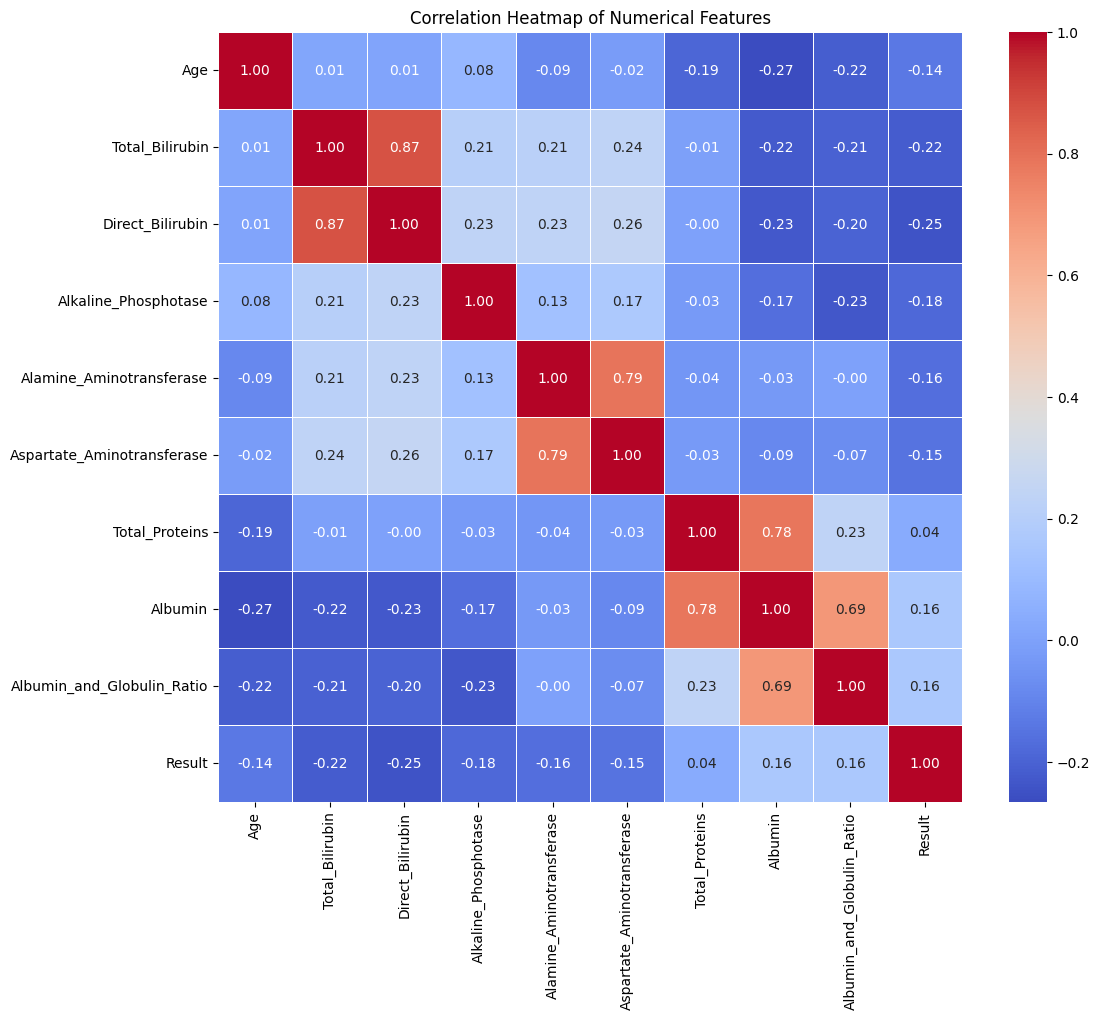

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
# Load the dataset
file_path = 'Indian Liver Patient Dataset (ILPD).csv'
column_names = [
    'Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
    'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins',
    'Albumin', 'Albumin_and_Globulin_Ratio', 'Result'
]

# The snippet suggests no header. Let's try reading it without header first.
df = pd.read_csv(file_path, names=column_names, header=None)

print(df.head())
print(df.info())

   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
1   62    Male             10.9               5.5                   699   
2   62    Male              7.3               4.1                   490   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Proteins  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   Albumin  Albumin_and_Globulin_Ratio  Result  
0      3.3                        0.90       1  


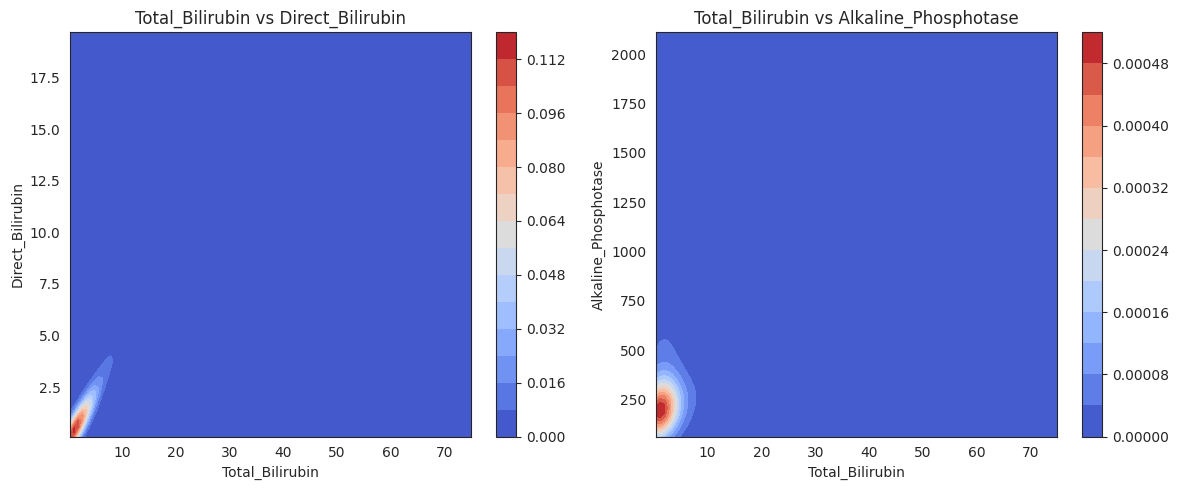

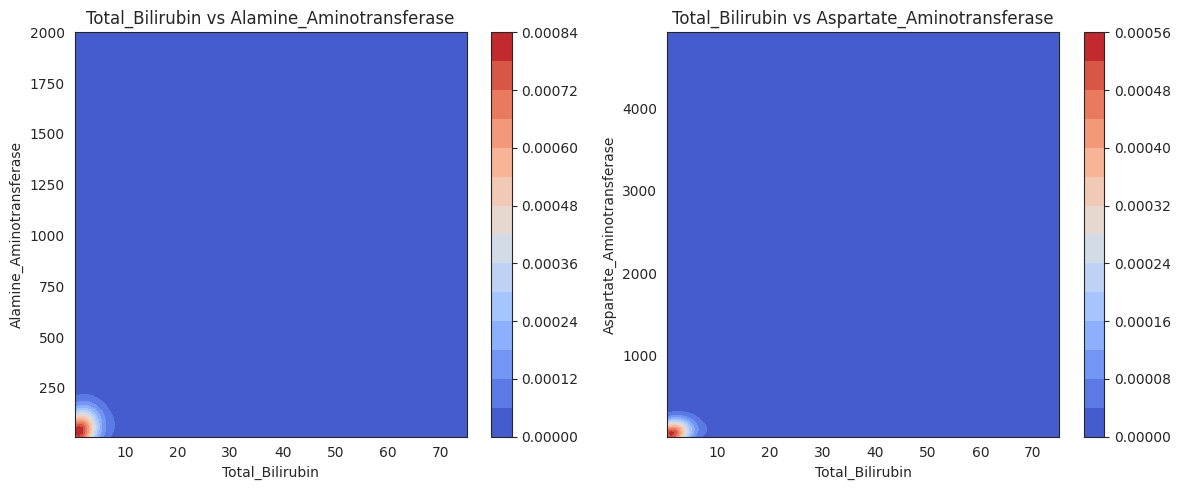

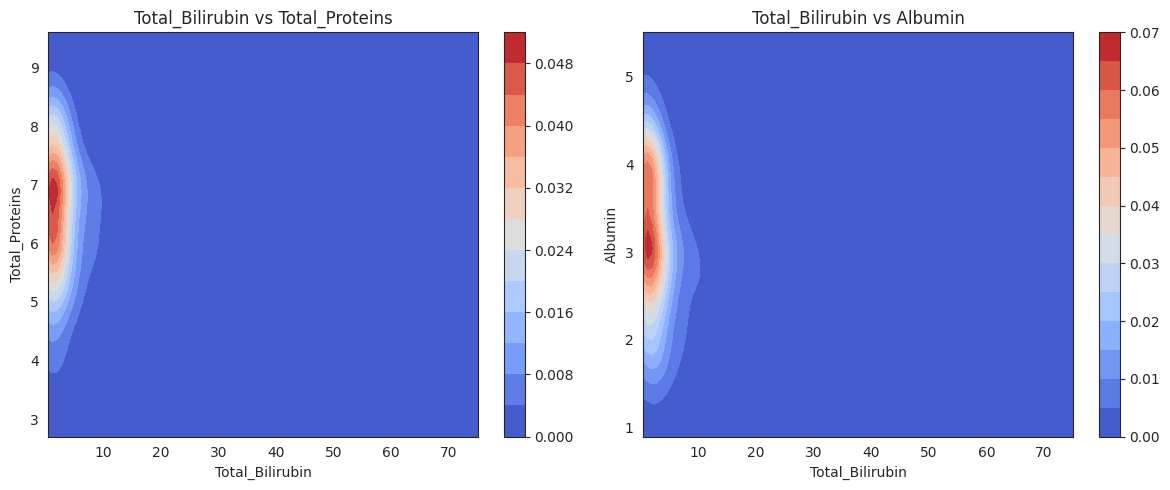

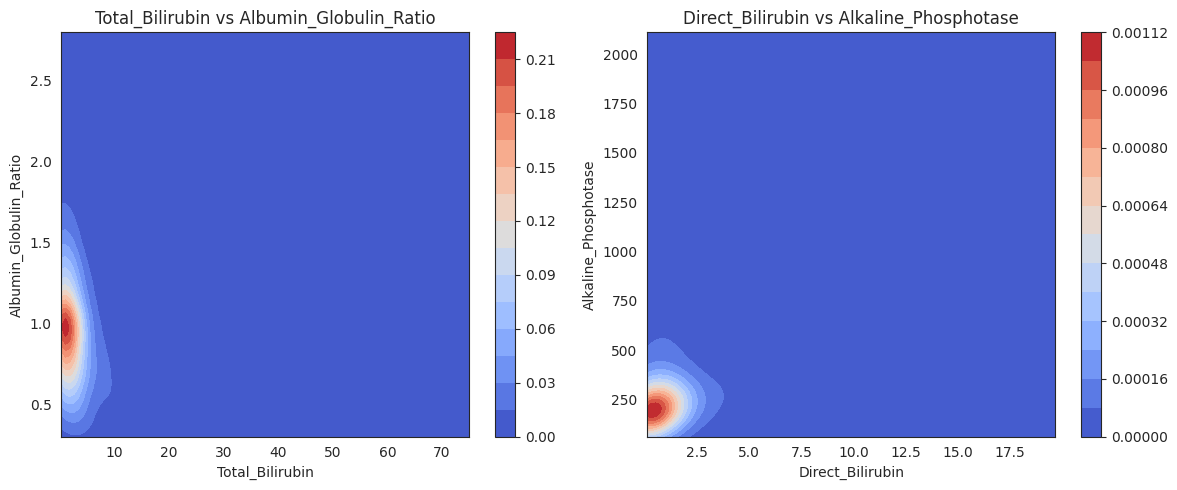

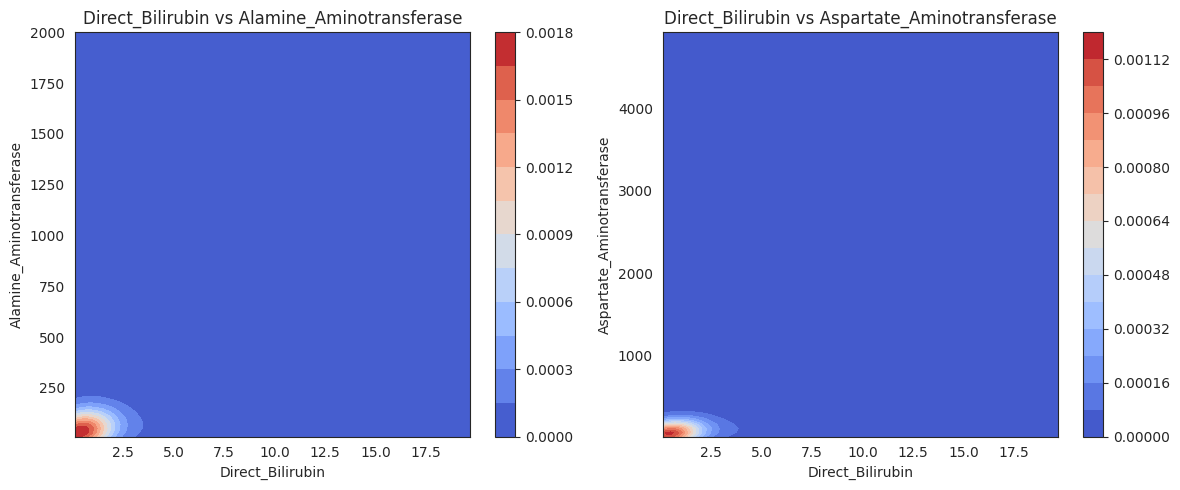

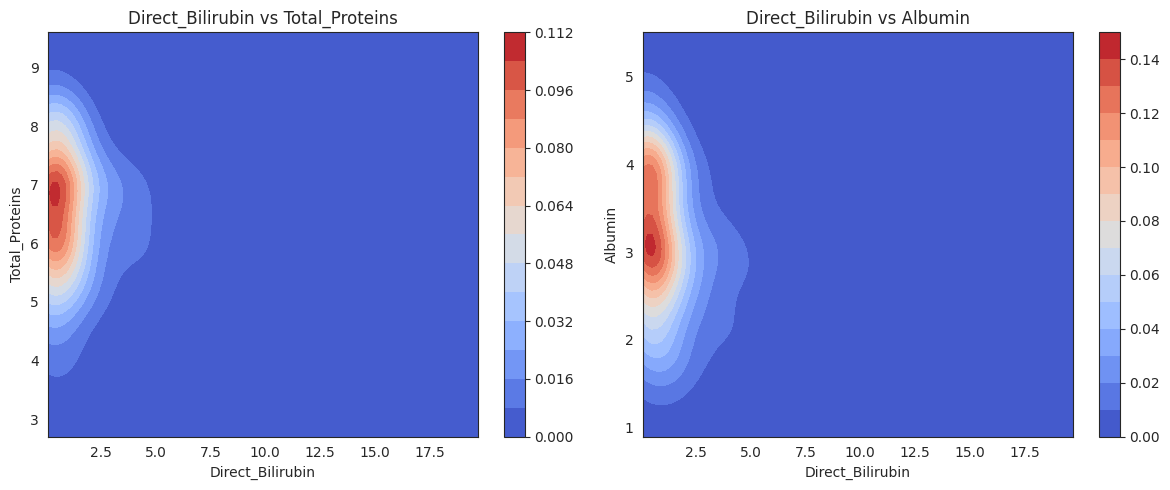

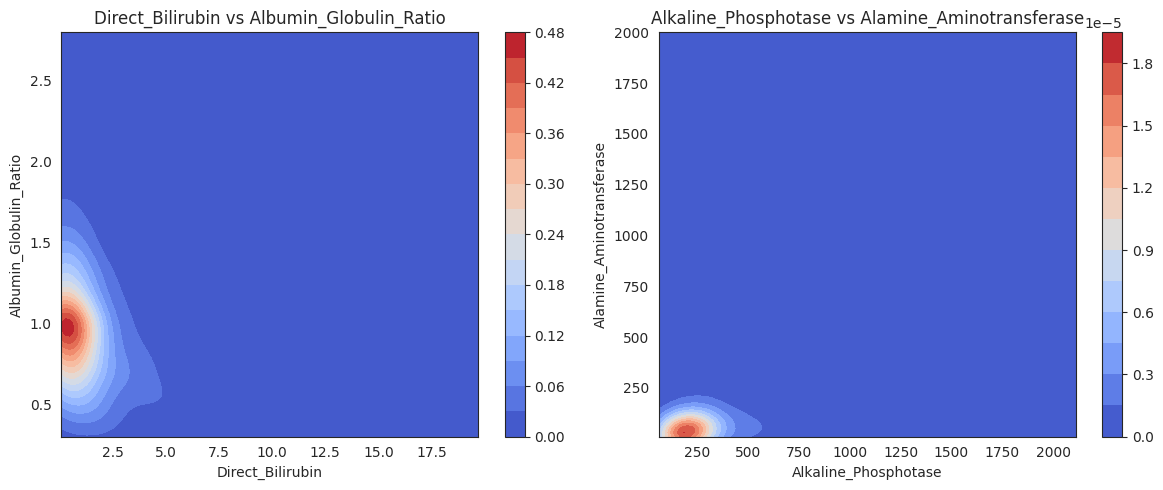

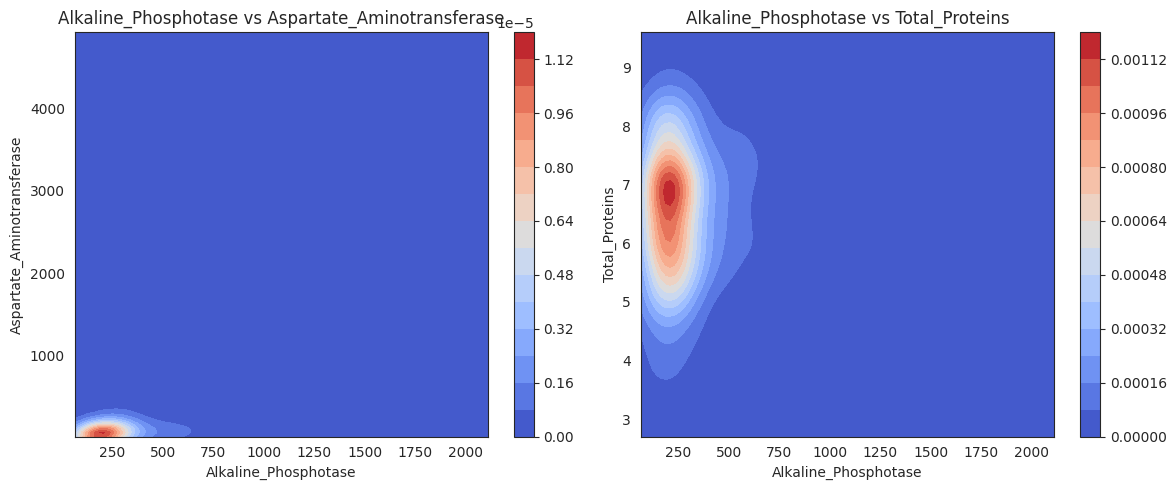

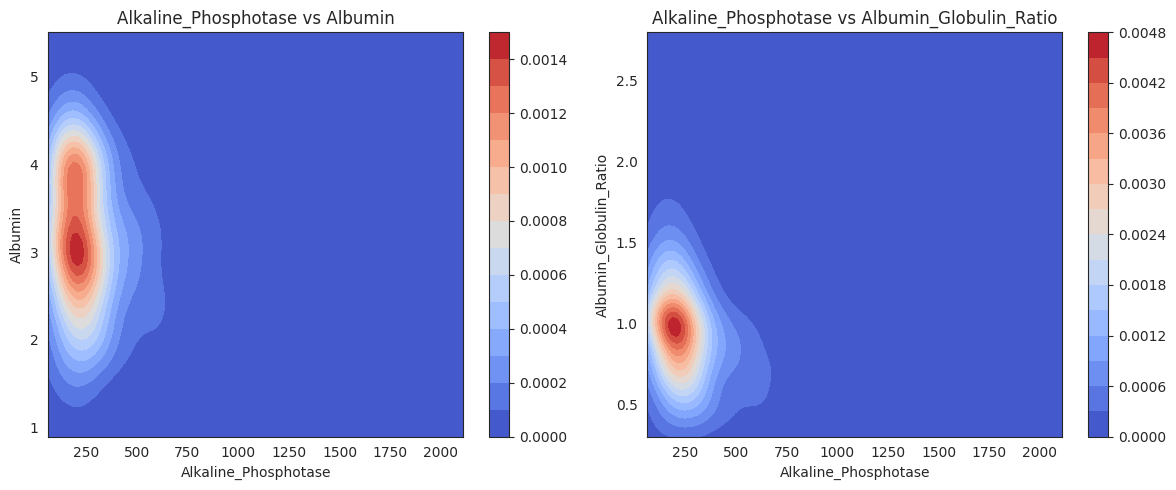

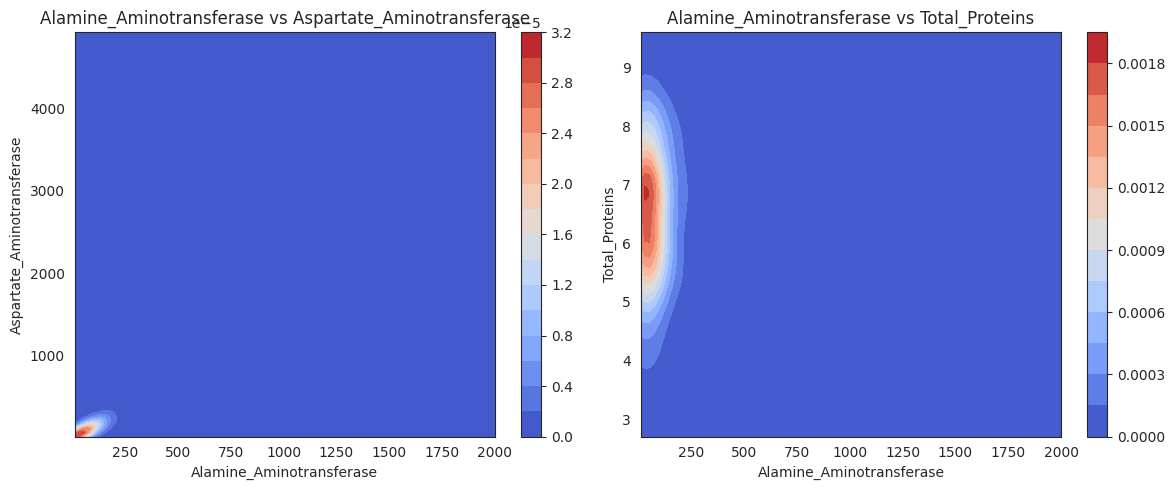

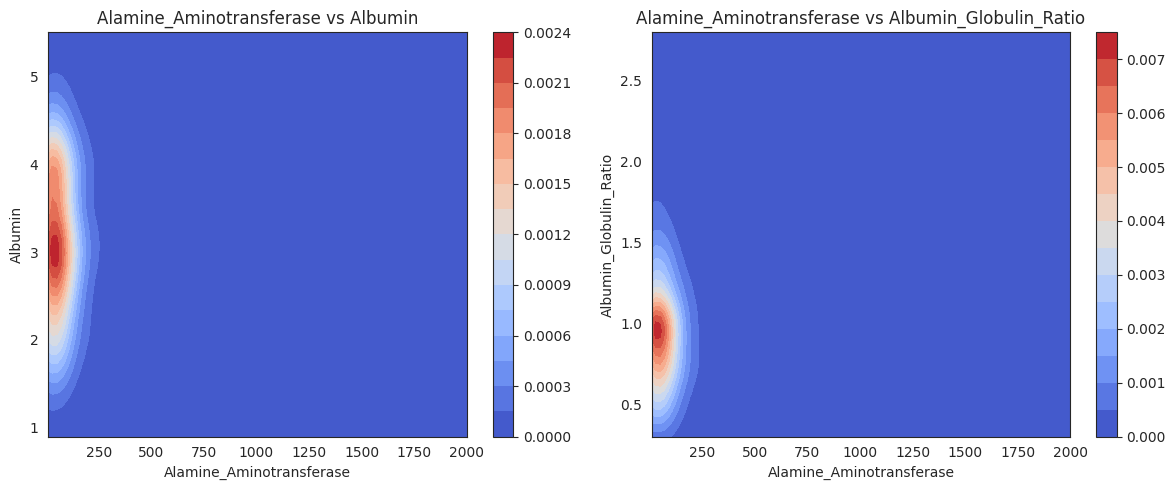

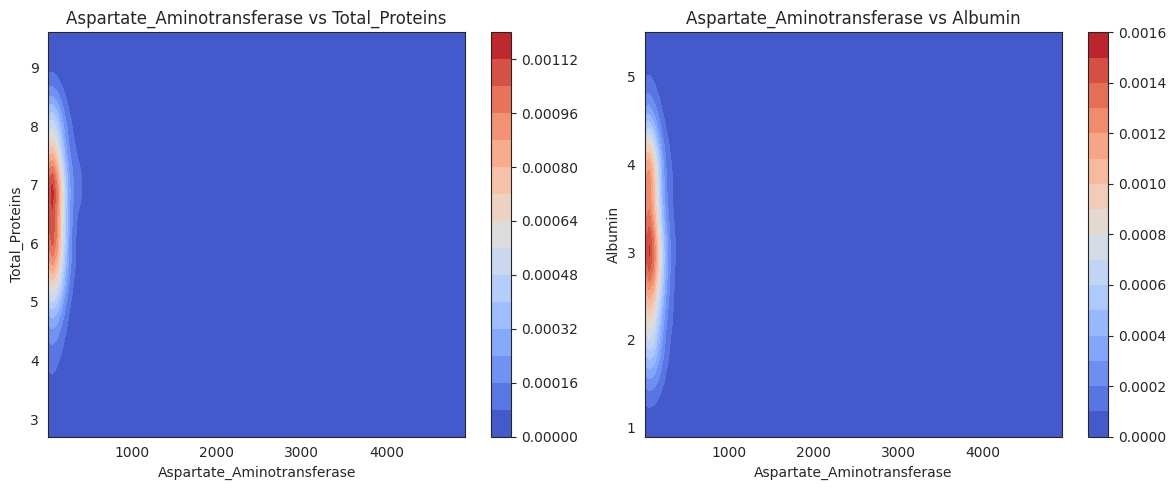

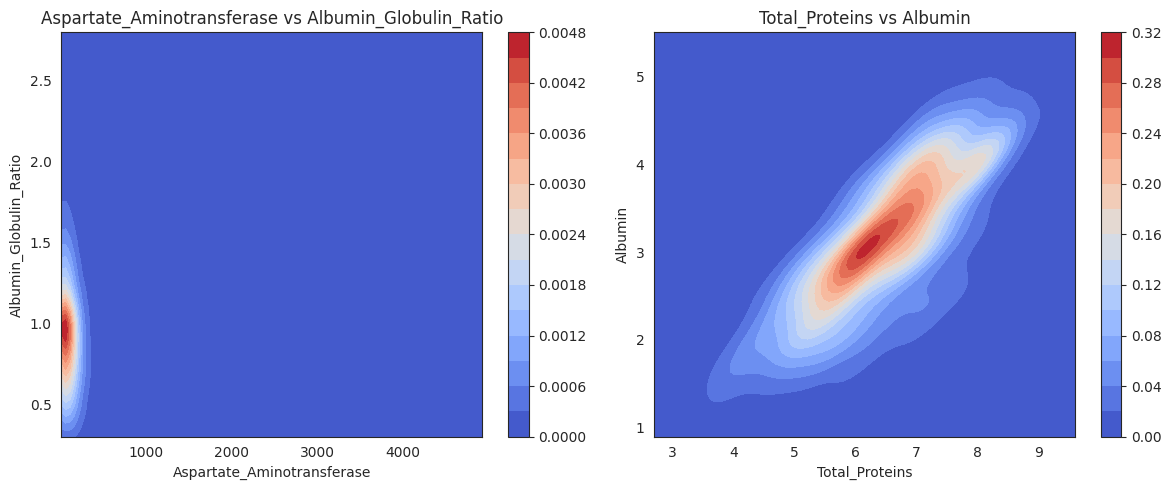

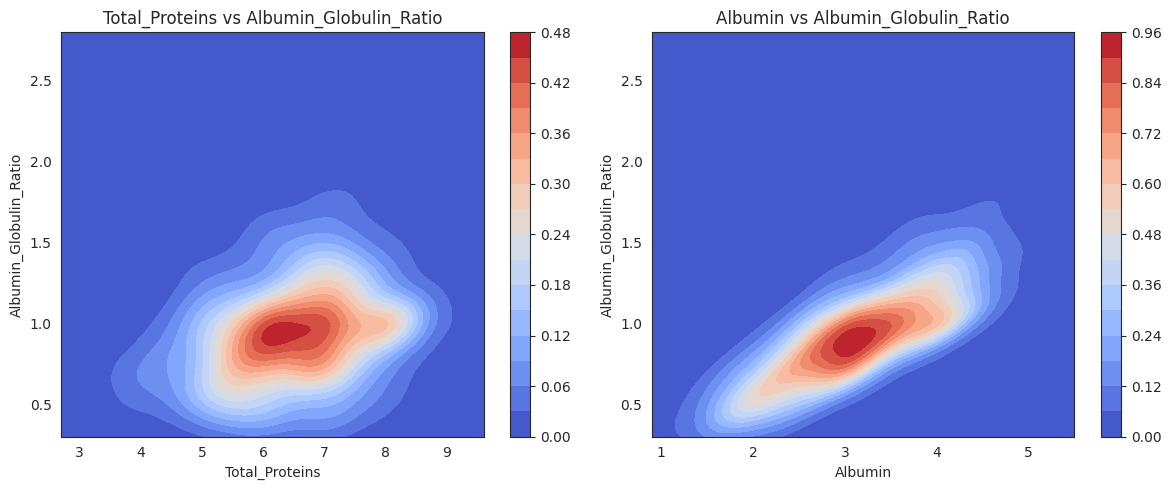

In [ ]:
from scipy.stats import gaussian_kde
from itertools import combinations

features = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_Globulin_Ratio"
]

pairs = list(combinations(features,2))

# Process two plots at a time
for i in range(0, len(pairs), 2):

    fig, axes = plt.subplots(1,2, figsize=(12,5))

    for j in range(2):

        if i+j >= len(pairs):
            break

        x_feature, y_feature = pairs[i+j]

        x = df[x_feature].values
        y = df[y_feature].values

        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()

        xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]

        positions = np.vstack([xx.ravel(), yy.ravel()])
        values = np.vstack([x,y])

        kernel = gaussian_kde(values)
        f = np.reshape(kernel(positions).T, xx.shape)

        contour = axes[j].contourf(xx, yy, f, levels=15, cmap="coolwarm")

        axes[j].set_title(f"{x_feature} vs {y_feature}")
        axes[j].set_xlabel(x_feature)
        axes[j].set_ylabel(y_feature)

        fig.colorbar(contour, ax=axes[j])

    plt.tight_layout()
    plt.show()

## Result wise plots

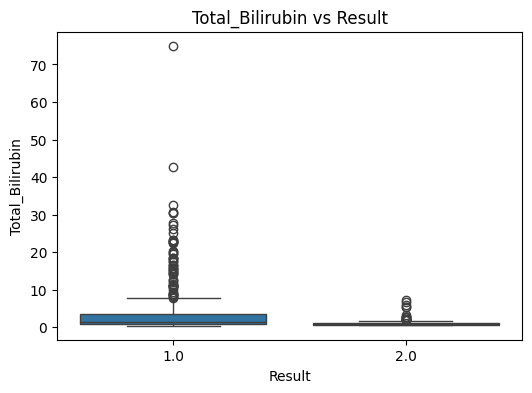

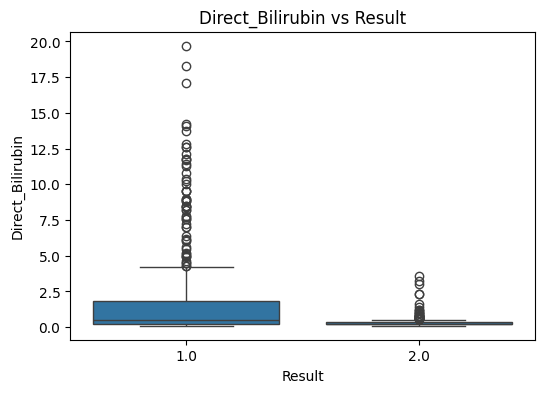

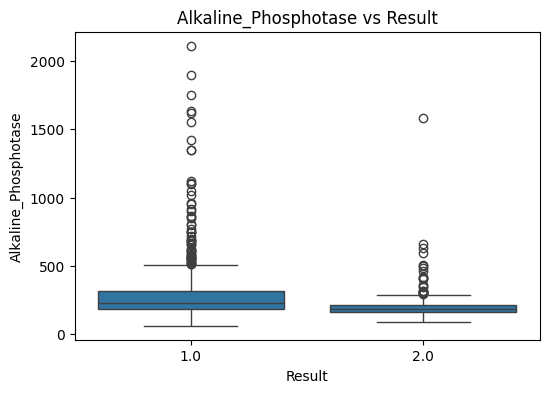

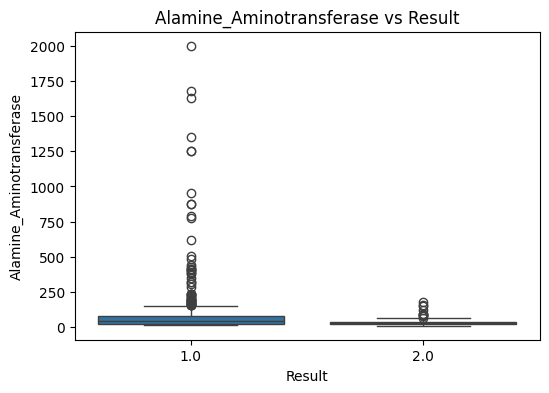

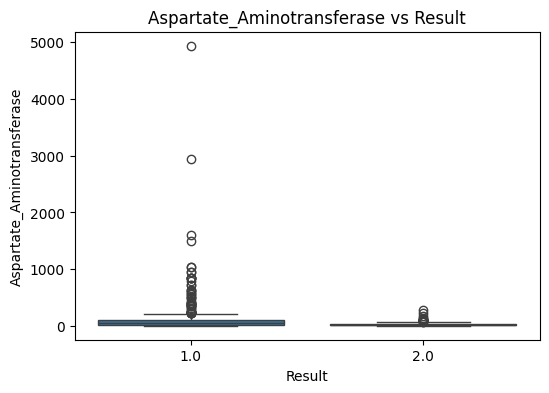

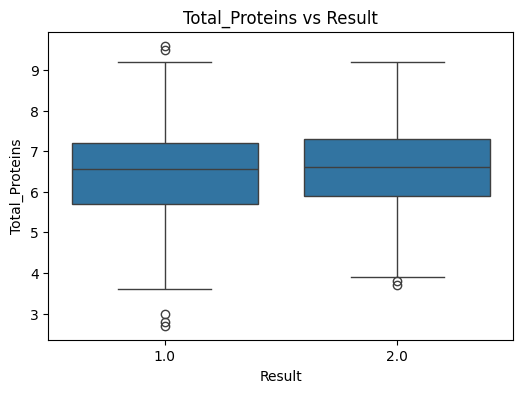

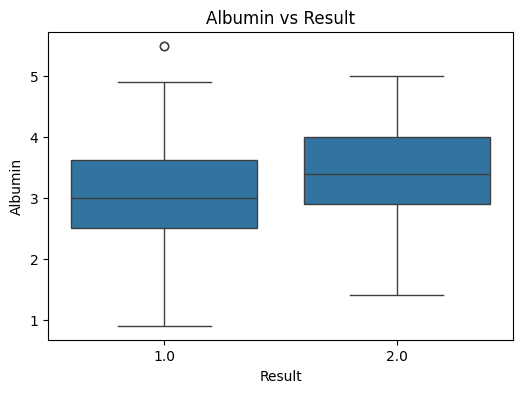

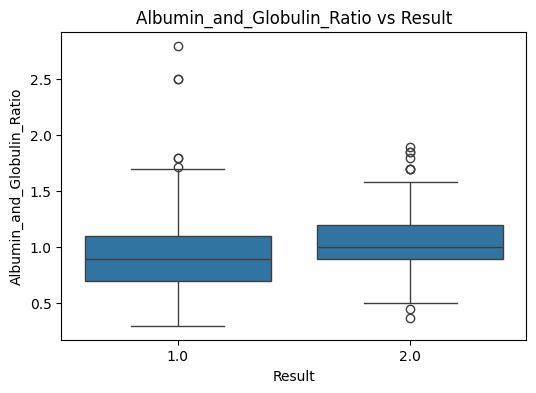

In [ ]:
# Define column names as they were in previous cells
column_names = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
    "Result"   # 1 = Liver disease, 2 = No liver disease
]

# Load the dataset, explicitly setting column names as the file has no header
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", names=column_names, header=None)

features = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_and_Globulin_Ratio"
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Result", y=col, data=df)
    plt.title(f"{col} vs Result")
    plt.show()

## Result and Gender wise plots

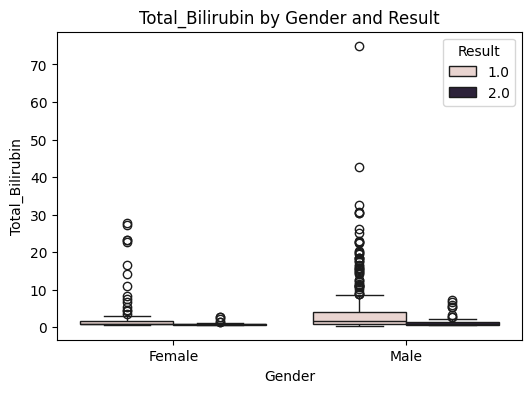

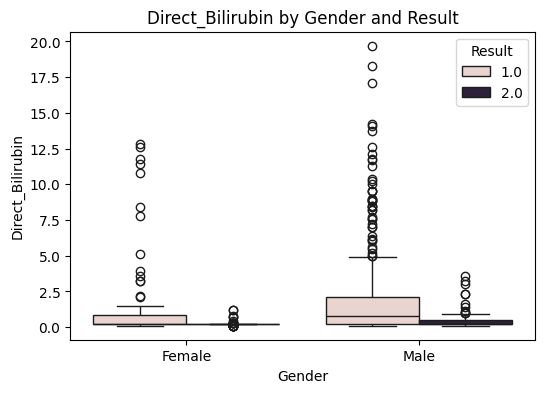

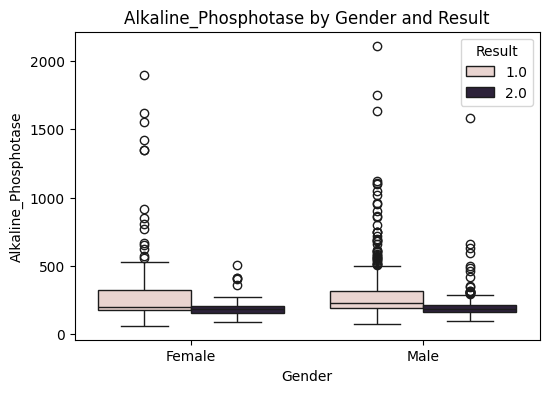

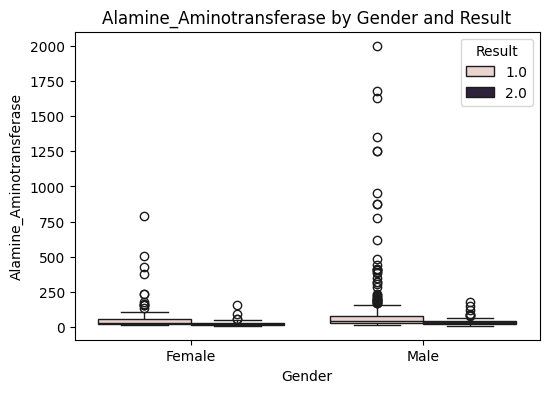

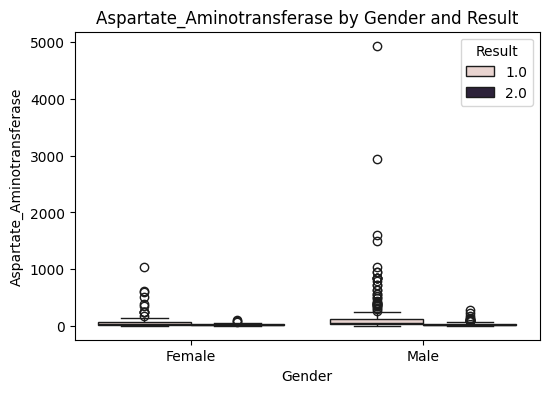

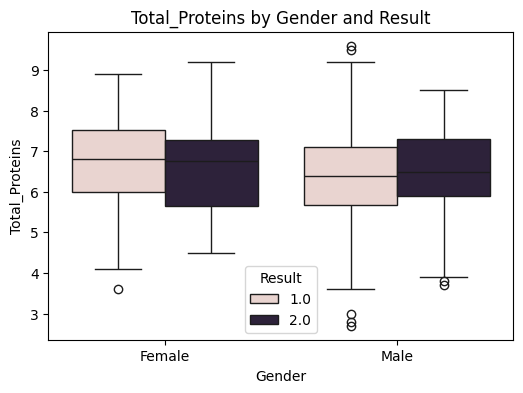

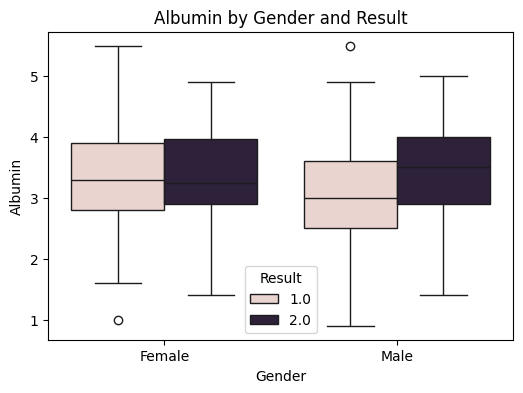

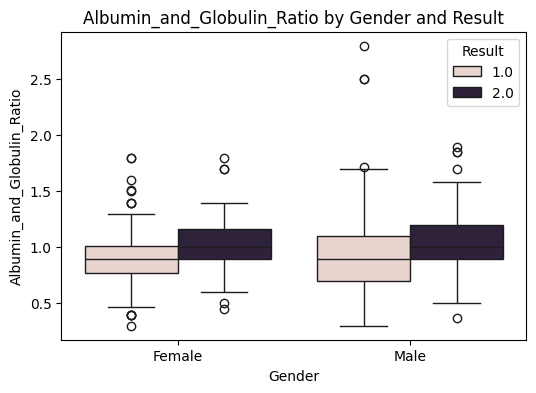

In [ ]:
for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Gender", y=col, hue="Result", data=df)
    plt.title(f"{col} by Gender and Result")
    plt.show()